# Introduction to Time Series Data

**Chapter Introduction**

The goal of this chapter is to **be able to predict time series data**. In this chapter, we will learn about the overview of time series data and feature engineering.

Goal: To understand what time series data is, and its feature engineering methods.

## Table of Contents
**[1.1 What is Time Series Data?](#8-1-what-is-time-series-data)**

**[1.2 Handling Time Series Data](#4-encoding-of-temporal-variables)**
> [1.2.1 Loading the Data](#8-1-2-1-encoding-without-considering-seasonality)<br>
> [1.2.2 Understanding the Data](#8-1-2-1-encoding-without-considering-seasonality)<br>

**[1.3 Encoding Time Series Data](#4-encoding-of-temporal-variables)**
> [1.3.1 Simple Encoding](#4.2-encoding-without-considering-seasonality)<br>
> [1.3.2 Cyclical Encoding](#4.3-encoding-considering-seasonality)

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
import matplotlib.pyplot as plt
%matplotlib inline

# Other settings
import warnings
warnings.filterwarnings('ignore')

## 1.1 What is Time Series Data?
Variables that have periodicity like time or date should be encoded in a way that reflects their structure.

Let's start by learning about handling time series data.

Keywords: Temporal changes, numerical data, images, audio, language

First, let's understand what time series data is.  

The tabular data we have been dealing with so far consists of individual records (rows) each having individual attributes, which generally do not change over time.  

On the other hand, **time series data**, as the name suggests, refers to **"data that changes over time"**.

There are a variety of time series data in the world.  

*   Stock price data: **numeric values** changing over time
*   Endoscopic images taken periodically: **images** changing over time
*   Audio data from factory floors: **sound** changing over time
*   Posts on X (formerly Twitter): **language** changing over time
*   etc...

In this lecture, we will mainly focus on "univariate time series data", where a single value changes over time.  

The figure below illustrates the difference between the tabular data we have been working with and univariate time series data.

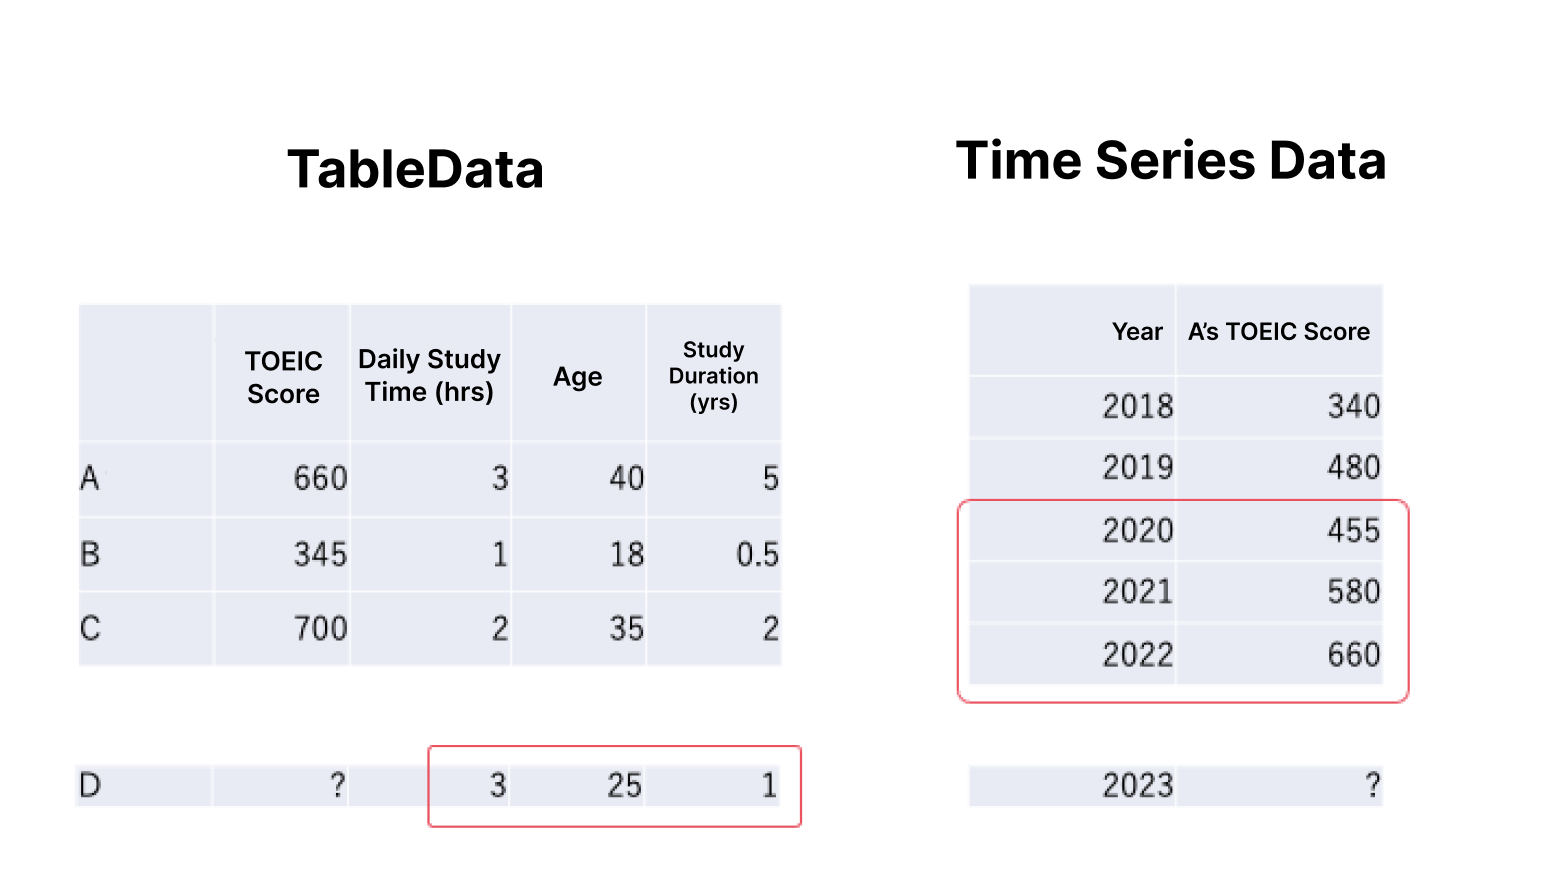

## 1.2 Handling Time Series Data

### 1.2.1 Loading the Data

Here, we will be dealing with the time-series data of PM2.5 concentrations in Beijing from January 1, 2010, 0:00 to December 31, 2014, 23:00.

The data we will be using is available in the following file:

https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv

Let's download and load this data.

In [2]:
import requests
import io
# Specify the URL where the data is located
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv'

# Fetch the data from the url
r = requests.get(url, stream=True).content
# Load the data into a DataFrame
beijing_pm25 = pd.read_csv(io.BytesIO(r))

The data includes hourly concentration values, with some missing values for certain hours. Use the `head()` method to display the first 5 rows of the beijing_pm25 dataset.

In [3]:
beijing_pm25.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In this section, we will only use the data from December, 2012. Let's first take a look at the first 5 rows of the data for December, 2012.

In [4]:
beijing_pm25.loc[(beijing_pm25['year'] == 2012) & (beijing_pm25['month'] == 12)].head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
25560,25561,2012,12,1,0,41.0,-16,-8.0,1035.0,NW,1.79,0,0
25561,25562,2012,12,1,1,46.0,-17,-7.0,1035.0,cv,0.89,0,0
25562,25563,2012,12,1,2,37.0,-15,-7.0,1036.0,cv,1.34,0,0
25563,25564,2012,12,1,3,48.0,-15,-9.0,1035.0,NE,0.89,0,0
25564,25565,2012,12,1,4,43.0,-14,-9.0,1035.0,NE,1.78,0,0


### 1.2.2 Understanding the Data

In the sample data, there are various columns and data spanning 5 years, but how to analyze it depends on the specific needs. For example, there may be a need to only extract the data from a certain month or year, or to only view values at the end of the month. Additionally, there may be a need to fill missing values with the preceding value, or to examine how much the value has increased compared to the previous day. All of these tasks can be easily calculated using Pandas.



To make analysis easier, we will combine the time data that is split into four columns: `year`, `month`, `day`, and `hour`, into a single datetime type column for easier handling. This column will be set as the index. We will store this as DataFrame `pm25`.

In [5]:
pm25 = pd.DataFrame(
    beijing_pm25['pm2.5'].values,
    index=pd.to_datetime(beijing_pm25[['year','month','day','hour']]),
    columns=['pm2.5']
)

Let's use the `head()` method again to double-check.

In [6]:
pm25.head()

,pm2.5
2010-01-01 00:00:00,NaN
2010-01-01 01:00:00,NaN
2010-01-01 02:00:00,NaN
2010-01-01 03:00:00,NaN
2010-01-01 04:00:00,NaN


Since all values are NaNs, we cannot tell if the data was correctly preprocessed. Let's refer to the data from December, 2012 to confirm.

#### Accessing Data for a Specific Year and Month

Here is how to access data for a specific year and month. If you only want to see the data for December 2012, specify the year and month as follows:

In [7]:
pm25_12_12 = pm25.loc['2012-12']
pm25_12_12.head()

,pm2.5
2012-12-01 00:00:00,41.0
2012-12-01 01:00:00,46.0
2012-12-01 02:00:00,37.0
2012-12-01 03:00:00,48.0
2012-12-01 04:00:00,43.0


You can also extract data for specific years or dates.

Next, let's extract only the final concentrations for each day. By specifying `D` as the argument for the `resample` method, we can extract daily data and use the `last` method to retrieve the last data point. Specifically, as we can see from below, we can extract the concentration at 23:00 for each day.

In [8]:
pm25_12_12.resample('D').last()

,pm2.5
2012-12-01,119.0
2012-12-02,313.0
2012-12-03,40.0
2012-12-04,39.0
2012-12-05,29.0
2012-12-06,158.0
2012-12-07,10.0
2012-12-08,16.0
2012-12-09,35.0
2012-12-10,129.0


When you want to extract the month, specify '`M`' as the argument, and when you want to extract the year, specify '`Y`'. This process of extracting data at a different frequency than the original data is called **resampling**. If you want to calculate the average instead of the last data, you can do so using the `mean()` method. You can set various parameters and explore them when needed for specific processes.

Time series data stored in numerical values can greatly enhance data understanding by plotting. Let's go ahead and plot it right away.

<Figure size 1000x500 with 0 Axes>

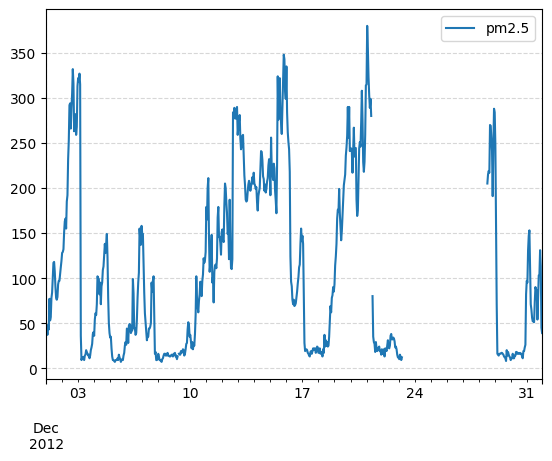

In [9]:
# Convert the index to datetime if necessary
pm25_12_12.index = pd.to_datetime(pm25_12_12.index)

# Adjust the size of the graph
plt.figure(figsize=(10, 5))

# Plot the data
pm25_12_12.plot()

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

# Display the graph
plt.show()

When you create a graph, you can examine the data in more detail. Firstly, you can clearly see where data is missing at the end of the month. Additionally, by visualizing the data, patterns like periods of high concentration followed by a sudden decrease over a few days will become apparent.

#### Dealing with Missing Values

Let's explore how to handle missing values in time series data. There are several methods for dealing with missing values. Here, we will use the last measurement of each day and perform various processes on 31 days of data. When you want to prepare data on a daily basis, you perform the resampling as we did earlier. Specifically, you can do the following:

In [10]:
pm25_12_12.resample('D').last()

,pm2.5
2012-12-01,119.0
2012-12-02,313.0
2012-12-03,40.0
2012-12-04,39.0
2012-12-05,29.0
2012-12-06,158.0
2012-12-07,10.0
2012-12-08,16.0
2012-12-09,35.0
2012-12-10,129.0


We can see that the data is missing from 2012/12/24 to 2012/12/27. We will fill these missing values with the previous day's value.

Here, we will use the `ffill()` method as shown below.

In [11]:
pm25_12_12.resample('D').last().ffill()

,pm2.5
2012-12-01,119.0
2012-12-02,313.0
2012-12-03,40.0
2012-12-04,39.0
2012-12-05,29.0
2012-12-06,158.0
2012-12-07,10.0
2012-12-08,16.0
2012-12-09,35.0
2012-12-10,129.0


#### Shifting Data

Next, let’s consider the case where we want to compare values with those of the previous day. For example, in this dataset, the PM2.5 concentration at 23:00 on 2012-12-01 is 119.0, while at 23:00 on 2012-12-02 it is 313.0, and we may wish to calculate their ratio. To perform this operation automatically for all dates, we can use the `shift()` method. The `shift()` method keeps the index fixed while shifting only the data. In the example below, the data is shifted by one day, so the concentration at 23:00 on 2012-12-01 (119.0) is treated as the value for 23:00 on 2012-12-02.

In [12]:
pm25_12_12.resample('D').last().shift(1).head()

,pm2.5
2012-12-01,NaN
2012-12-02,119.0
2012-12-03,313.0
2012-12-04,40.0
2012-12-05,39.0


By processing the data this way, we can compute the ratio of the previous day's concentration to the current day's concentration in one go. Note that the value for 2012-12-01 becomes NaN since there is no data available for the day before.

In [13]:
pm25_ratio = pm25_12_12.resample('D').last() / pm25_12_12.resample('D').last().shift(1)
pm25_ratio.head()

,pm2.5
2012-12-01,NaN
2012-12-02,2.630252
2012-12-03,0.127796
2012-12-04,0.975000
2012-12-05,0.743590


There are other methods available to calculate differences or ratios, such as `diff` and `pct_change`. If you are interested, please look into them.

#### <Practice Question 8-1-1>

Using the DataFrame `pm25` created as above, create a DataFrame showing the trend of average values per year.

In [14]:
# write me!

#### Moving Average
Next, let's look at how to calculate moving averages, which are frequently used in time series data processing. Using the PM2.5 data we saw earlier, we will create a 3-hour moving average line. First, let's extract the first five rows:

In [15]:
pm25_12_12.head()

,pm2.5
2012-12-01 00:00:00,41.0
2012-12-01 01:00:00,46.0
2012-12-01 02:00:00,37.0
2012-12-01 03:00:00,48.0
2012-12-01 04:00:00,43.0


Looking at the results, you can see that the values up to 2:00 on 2012-12-01 are 41.0 at 0:00, 46.0 at 1:00, and 37.0 at 2:00. Their average is (41.0 + 46.0 + 37.0) / 3 = 41.333.

In the same way, you can continue calculating for 3:00, 4:00, and so on. Instead of doing this by hand, you can easily compute it using Pandas' `rolling()` method. Below is the result of calculating the 3-hour moving average, obtained by first applying the `rolling()` method and then using the mean method:

In [16]:
pm25_12_12.rolling(3).mean().head()

,pm2.5
2012-12-01 00:00:00,NaN
2012-12-01 01:00:00,NaN
2012-12-01 02:00:00,41.333333
2012-12-01 03:00:00,43.666667
2012-12-01 04:00:00,42.666667


If instead of the moving average you want to calculate the moving standard deviation, you can use the `std()` method in place of `mean()`. Below is the 3-hour moving standard deviation:

In [17]:
pm25_12_12.rolling(3).std().head()

,pm2.5
2012-12-01 00:00:00,NaN
2012-12-01 01:00:00,NaN
2012-12-01 02:00:00,4.509250
2012-12-01 03:00:00,5.859465
2012-12-01 04:00:00,5.507571


The `rolling()` method has various other parameters, so feel free to research and try them out as needed.

#### <Practice Question 8-1-2>

Using the `pm25` data used in <Practice Question 8-1-1>, create a 20-day moving average dataset. Remove any `NaN` values. There is no need to fill in missing data that does not exist as a record.

In [18]:
# write me!

## 1.3 Encoding Time Series Data

### 1.3.1 Simple Encoding
So far, we have covered how to handle time series data. Now, let's study how to deal with features that have time series properties. Let's first look at some encoding methods that do not consider periodicity.

The simplest encoding method is to use numerical variables for each year, month, and day.

Here, we will look at encoding methods for time variables using the date as an example.

First, as the sample data we will be working with, we will randomly select 10 dates from the 2010s decade.

In [19]:
import datetime
import random

# Function to output a random date between start and end
def generate_rand_date(start, end):
    days_delta = (end - start).days
    return start + datetime.timedelta(days=random.randint(0, days_delta))

# Fix the random seed and get 10 random dates in the 2010s
random.seed(0)
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2020, 12, 31)
random_dates = [generate_rand_date(start, end) for _ in range(10)]

# Convert date data to a DataFrame
df_dates = DataFrame(random_dates, columns=['ymd'])
df_dates

,ymd
0,2019-06-21
1,2014-04-27
2,2018-07-02
3,2019-12-26
4,2014-09-19
5,2010-06-15
6,2012-11-26
7,2020-10-29
8,2015-09-26
9,2015-06-14


In [20]:
# Splitting the year, month, and day from the date
df_dates['year'] = df_dates['ymd'].apply(lambda x: x.year)
df_dates['month'] = df_dates['ymd'].apply(lambda x: x.month)
df_dates['day'] = df_dates['ymd'].apply(lambda x: x.day)

df_dates

,ymd,year,month,day
0,2019-06-21,2019,6,21
1,2014-04-27,2014,4,27
2,2018-07-02,2018,7,2
3,2019-12-26,2019,12,26
4,2014-09-19,2014,9,19
5,2010-06-15,2010,6,15
6,2012-11-26,2012,11,26
7,2020-10-29,2020,10,29
8,2015-09-26,2015,9,26
9,2015-06-14,2015,6,14


By doing this, we can now treat each year, month, and day as numerical variables. However, there are two major issues with this approach:

1. The information of year, month, and day is separate, making it difficult to learn their chronological order. For example, it does not capture the fact that January 1, 2010, and January 1, 2020, are far apart chronologically.
2. Discontinuities occur in parts that should be continuous as a time series. For example, it does not capture the fact that January and December, or the 1st and 31st of a month, are close to each other in a cyclical sense.

To address the former, we can use a method that involves creating a new variable representing the difference from a reference point. By encoding in this way, we can represent the information of how old or new a date is. Since we are dealing with dates this time, let's take January 1, 2010, as the reference date and consider the difference as a new variable.

In [21]:
# Set the reference date to January 1, 2010
start_date = pd.Timestamp('2010-01-01 00:00:00')

# Store the difference from the reference date
df_dates['total_days'] = df_dates['ymd'].apply(lambda x: (x - start_date).days)

df_dates

,ymd,year,month,day,total_days
0,2019-06-21,2019,6,21,3458
1,2014-04-27,2014,4,27,1577
2,2018-07-02,2018,7,2,3104
3,2019-12-26,2019,12,26,3646
4,2014-09-19,2014,9,19,1722
5,2010-06-15,2010,6,15,165
6,2012-11-26,2012,11,26,1060
7,2020-10-29,2020,10,29,3954
8,2015-09-26,2015,9,26,2094
9,2015-06-14,2015,6,14,1990


By doing this, we were able to explicitly encode chronological information, from old to new. Next, let's address the latter issue by also utilizing encoding methods that take into account periodicity.

### 1.3.2 Cyclical Encoding
To encode the periodic structure of time variables, trigonometric functions can be used.
Variables with periodicity such as months and days are mapped to points on the unit circle and represented by the coordinates of each point.
The coordinates of each point are represented by cosine and sine, which are then used as new numerical variables.

In [22]:
df_dates['month_cos'] = df_dates['month'].apply(lambda x: np.cos(2*np.pi * x/12))
df_dates['month_sin'] = df_dates['month'].apply(lambda x: np.sin(2*np.pi * x/12))

df_dates['day_cos'] = df_dates['day'].apply(lambda x: np.cos(2*np.pi * x/31))
df_dates['day_sin'] = df_dates['day'].apply(lambda x: np.sin(2*np.pi * x/31))

df_dates

,ymd,year,month,day,total_days,month_cos,month_sin,day_cos,day_sin
0,2019-06-21,2019,6,21,3458,-1.000000e+00,1.224647e-16,-0.440394,-0.897805
1,2014-04-27,2014,4,27,1577,-5.000000e-01,8.660254e-01,0.688967,-0.724793
2,2018-07-02,2018,7,2,3104,-8.660254e-01,-5.000000e-01,0.918958,0.394356
3,2019-12-26,2019,12,26,3646,1.000000e+00,-2.449294e-16,0.528964,-0.848644
4,2014-09-19,2014,9,19,1722,-1.836970e-16,-1.000000e+00,-0.758758,-0.651372
5,2010-06-15,2010,6,15,165,-1.000000e+00,1.224647e-16,-0.994869,0.101168
6,2012-11-26,2012,11,26,1060,8.660254e-01,-5.000000e-01,0.528964,-0.848644
7,2020-10-29,2020,10,29,3954,5.000000e-01,-8.660254e-01,0.918958,-0.394356
8,2015-09-26,2015,9,26,2094,-1.836970e-16,-1.000000e+00,0.528964,-0.848644
9,2015-06-14,2015,6,14,1990,-1.000000e+00,1.224647e-16,-0.954139,0.299363


In this way, we were able to encode the time variable considering the periodic structure.